# **Importar librerias**

In [23]:
import time
import random
from datetime import datetime, timedelta
import numpy as np
import pandas as pd


from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler


import plotly.graph_objs as go
from plotly.subplots import make_subplots


from IPython.display import display, clear_output

## **Simular datos**

Crear dataset con datos básicos de monitoreo para hacer las pruebas de datos.

In [24]:
def generate_advanced_network_data(
    n_records=10000,
    regions=("Bogotá", "Medellín", "Cali", "Barranquilla"),
    services=("voz", "datos", "tv"),
    seed=42
):
    np.random.seed(seed)
    random.seed(seed)

    start_time = datetime.utcnow() - timedelta(hours=n_records / 60)
    timestamps = [start_time + timedelta(seconds=i*10) for i in range(n_records)]

    data = []
    for i in range(n_records):
        region = random.choice(regions)
        service = random.choice(services)

        # Simular picos de tráfico por hora
        hour = timestamps[i].hour
        peak_factor = 1.2 if 18 <= hour <= 22 else 0.8

        # Métricas base
        latency = np.random.normal(40, 10) * peak_factor
        jitter = np.random.normal(5, 2)
        packet_loss = np.random.beta(1, 100) * 100
        throughput = np.random.normal(80, 20) / peak_factor
        cpu = np.random.normal(50, 15)
        mem = np.random.normal(60, 10)
        active_users = int(np.random.normal(5000, 800) * peak_factor)

        status = 0
        # Introducir fallas correlacionadas en ciertos periodos
        if random.random() < 0.005:
            latency *= np.random.uniform(2, 4)
            packet_loss += np.random.uniform(5, 30)
            jitter += np.random.uniform(10, 30)
            throughput *= 0.3
            cpu += 20
            mem += 15
            status = 1

        data.append([
            timestamps[i], region, service,
            round(latency, 2), round(jitter, 2), round(packet_loss, 2),
            round(throughput, 2), active_users,
            round(cpu, 2), round(mem, 2), status
        ])

    df = pd.DataFrame(data, columns=[
        "timestamp", "region", "service_type",
        "latency_ms", "jitter_ms", "packet_loss", "throughput_mbps",
        "active_users", "cpu_usage", "memory_usage", "status"
    ])

    return df

# DataFrame

In [25]:
df = generate_advanced_network_data()

/tmp/ipython-input-3199195605.py:10: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [26]:
df

,timestamp,region,service_type,latency_ms,jitter_ms,packet_loss,throughput_mbps,active_users,cpu_usage,memory_usage,status
0,2025-10-11 06:04:20.281668,Bogotá,voz,35.97,4.72,1.46,107.97,3699,73.69,67.67,0
1,2025-10-11 06:04:30.281668,Medellín,voz,36.34,4.07,0.38,56.88,4201,41.57,49.87,0
2,2025-10-11 06:04:40.281668,Bogotá,tv,24.74,2.18,0.65,114.94,3263,41.83,61.11,0
3,2025-10-11 06:04:50.281668,Bogotá,tv,35.01,3.80,1.18,99.66,3218,34.13,68.23,0
4,2025-10-11 06:05:00.281668,Bogotá,voz,33.67,1.08,0.77,122.04,3053,48.27,56.99,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2025-10-12 09:50:10.281668,Medellín,datos,38.05,3.49,1.20,87.55,4100,61.80,48.36,0
9996,2025-10-12 09:50:20.281668,Bogotá,tv,29.01,5.30,1.95,103.76,4652,25.83,54.23,0
9997,2025-10-12 09:50:30.281668,Bogotá,tv,36.57,4.30,0.18,108.01,4517,55.29,74.80,0
9998,2025-10-12 09:50:40.281668,Bogotá,datos,15.11,7.19,0.27,106.06,4565,60.61,55.20,0


Información de los datos

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        10000 non-null  datetime64[ns]
 1   region           10000 non-null  object        
 2   service_type     10000 non-null  object        
 3   latency_ms       10000 non-null  float64       
 4   jitter_ms        10000 non-null  float64       
 5   packet_loss      10000 non-null  float64       
 6   throughput_mbps  10000 non-null  float64       
 7   active_users     10000 non-null  int64         
 8   cpu_usage        10000 non-null  float64       
 9   memory_usage     10000 non-null  float64       
 10  status           10000 non-null  int64         
dtypes: datetime64[ns](1), float64(6), int64(2), object(2)
memory usage: 859.5+ KB


# **Modelo predictivo**

## Análisis exploratorio de datos

**¿Qué relación existe entre la latencia y la zona donde estan ubicados los clientes? ¿Qué relación tiene la latencia y el jitter con la zona?**

In [28]:
# Boxplot de Latencia por Región
fig_latency = go.Figure()
for region in df['region'].unique():
    fig_latency.add_trace(go.Box(
        y=df[df['region'] == region]['latency_ms'],
        name=region,
        boxpoints= False
    ))

fig_latency.update_layout(
    title='Distribución de Latencia por Región',
    yaxis_title='Latencia (ms)'
)
fig_latency.show()

# Boxplot de Jitter por Región
fig_jitter = go.Figure()
for region in df['region'].unique():
    fig_jitter.add_trace(go.Box(
        y=df[df['region'] == region]['jitter_ms'],
        name=region,
        boxpoints= False
    ))

fig_jitter.update_layout(
    title='Distribución de Jitter por Región',
    yaxis_title='Jitter (ms)'
)
fig_jitter.show()

La mediana no varía significativamente entre ciudades, sin embargo si varía el rango intercuartilico de los bigotes, siendo la cantidad de dispoersión de datos más alta en Bogotá que en el resto de las ciudades.
Por lo tanto Bogotá tiene más latencia que el resto de las ciudades.

De forma inversa en ciudades que presentan menos latencia tiene mas jitter (retardo en paquetes) en sus estadísticas por lo tanto la estabilidad de paquetes se ve afectada.

**¿Cuál es e el servicio con más perdida de datos?**

In [29]:
packet_loss_by_service_region = df.groupby(['region', 'service_type'])['packet_loss'].mean().reset_index()

fig = go.Figure(data=[
    go.Bar(name=service, x=packet_loss_by_service_region[packet_loss_by_service_region['service_type'] == service]['region'], y=packet_loss_by_service_region[packet_loss_by_service_region['service_type'] == service]['packet_loss'])
    for service in packet_loss_by_service_region['service_type'].unique()
])

fig.update_layout(
    barmode='group',
    title='Pérdida de Datos Promedio por Servicio y Región',
    xaxis_title='Región',
    yaxis_title='Pérdida de Paquetes (%)'
)

fig.show()

**Insights**



*   La ciudad que tiene más perdidas en datos es Cali
*   La ciudad con más oerdida de datos en tv es Medellín
*   La ciudad con más perdida de datos en voz es Bogotá
* Barranquilla presenta un nivel constante de perdidas entre tv y voz



**¿Cuál es la relación entre las variables del sistema (uso de CPU y memoria) con la caída del sistema?**

In [30]:
correlation_matrix = df[['cpu_usage', 'memory_usage', 'status']].corr()
display(correlation_matrix)

,cpu_usage,memory_usage,status
cpu_usage,1.000000,-0.002825,0.078129
memory_usage,-0.002825,1.000000,0.100705
status,0.078129,0.100705,1.000000


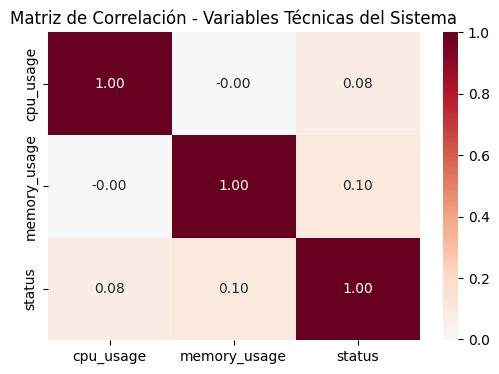

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular correlación
correlation_matrix = df[['cpu_usage', 'memory_usage', 'status']].corr()

# Crear el heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    correlation_matrix,
    annot=True,          # Muestra los valores dentro de cada celda
    cmap='RdBu_r',       # Escala de color
    center=0,            # Centra el color en cero
    fmt=".2f"
)
plt.title('Matriz de Correlación - Variables Técnicas del Sistema')
plt.show()


- La CPU no está relacionada con la caída del sistema

In [32]:
network_correlation_matrix = df[['latency_ms', 'jitter_ms', 'packet_loss', 'throughput_mbps', 'status']].corr()
display(network_correlation_matrix)

,latency_ms,jitter_ms,packet_loss,throughput_mbps,status
latency_ms,1.000000,0.216810,0.307667,-0.304457,0.393509
jitter_ms,0.216810,1.000000,0.381306,-0.088236,0.531050
packet_loss,0.307667,0.381306,1.000000,-0.121995,0.739471
throughput_mbps,-0.304457,-0.088236,-0.121995,1.000000,-0.163747
status,0.393509,0.531050,0.739471,-0.163747,1.000000


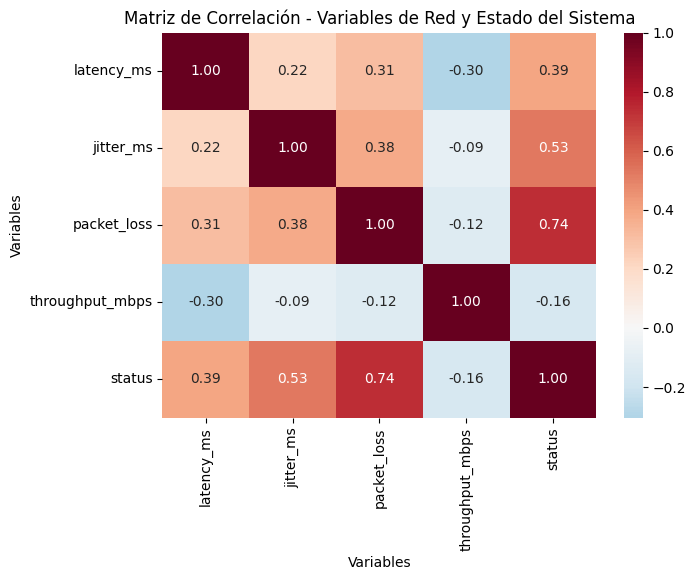

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular matriz de correlación
network_correlation_matrix = df[['latency_ms', 'jitter_ms', 'packet_loss', 'throughput_mbps', 'status']].corr()

# Crear el heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    network_correlation_matrix,
    annot=True,          # Muestra los valores en cada celda
    cmap='RdBu_r',       # Escala de color rojo-azul inversa (rojo = positivo, azul = negativo)
    center=0,            # Centra el color en cero
    fmt=".2f"
)
plt.title('Matriz de Correlación - Variables de Red y Estado del Sistema')
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.show()


- El estado y la pérdida de paquetes estan altamente relacionado con la caída del sistema.
- Además del estado del sistema y el jitter.
- La latencia esta medianamente relacionada a la caída del sistema.

## **Modelo predictivo de la caída del sistema en tiempo real**

## Importar librerias

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


Dividir los datos

In [89]:
# Variables predictoras y objetivo
X = df[['cpu_usage', 'memory_usage', 'latency_ms', 'jitter_ms', 'packet_loss', 'throughput_mbps']]
y = df['status']

# División estratificada para mantener proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)
print("Distribución de clases en train:\n", y_train.value_counts(normalize=True))


Tamaño de entrenamiento: (7000, 6)
Tamaño de prueba: (3000, 6)
Distribución de clases en train:
 status
0    0.995571
1    0.004429
Name: proportion, dtype: float64


Crear el pipeline de preprocesamiento de datos

In [90]:
# Pipeline con SMOTE dentro (evita fuga de información)
pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])
pipeline


Pipeline(steps=[('smote', SMOTE(random_state=42)), ('scaler', StandardScaler()),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

Rejilla para evitar overfitting

In [91]:
# Hiperparámetros a evaluar
param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [4, 6, 10],           # limitar profundidad
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 0.8]      # controlar complejidad
}


Hiperparametros y validación cruzada

In [92]:
# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV con F1 como métrica (importante en clases desbalanceadas)
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    verbose=2,
    n_jobs=-1,
    return_train_score=True
)


Entrenar el modelo (busqueda con hiperparametros)

In [93]:
# Entrenamiento con búsqueda
grid.fit(X_train, y_train)

print("Mejor F1-score (validación cruzada):", round(grid.best_score_, 3))
print("Mejores hiperparámetros:", grid.best_params_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejor F1-score (validación cruzada): 1.0
Mejores hiperparámetros: {'rf__max_depth': 4, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}


🔹 Reporte de Clasificación (Test):

              precision    recall  f1-score   support

           0      1.000     1.000     1.000      2986
           1      1.000     1.000     1.000        14

    accuracy                          1.000      3000
   macro avg      1.000     1.000     1.000      3000
weighted avg      1.000     1.000     1.000      3000



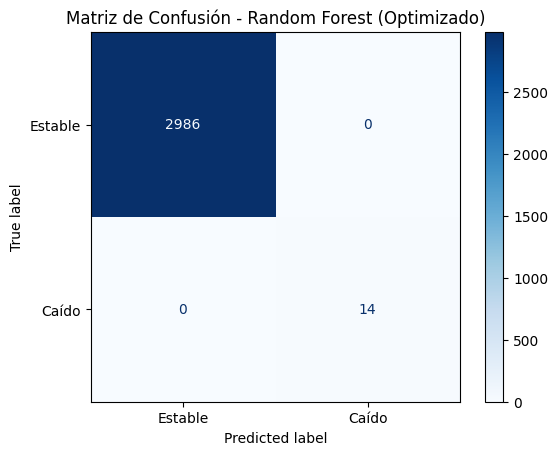

ROC-AUC: 1.000
Average Precision (PR-AUC): 1.000


In [94]:
# Modelo óptimo
best_model = grid.best_estimator_

# Predicciones
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Reporte de Clasificación
print("🔹 Reporte de Clasificación (Test):\n")
print(classification_report(y_test, y_pred, digits=3))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Estable", "Caído"])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Random Forest (Optimizado)")
plt.show()

# AUC y Precision-Recall
roc_auc = roc_auc_score(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Average Precision (PR-AUC): {ap_score:.3f}")
